# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree



plt.rcParams['figure.figsize'] = (10, 6)

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero

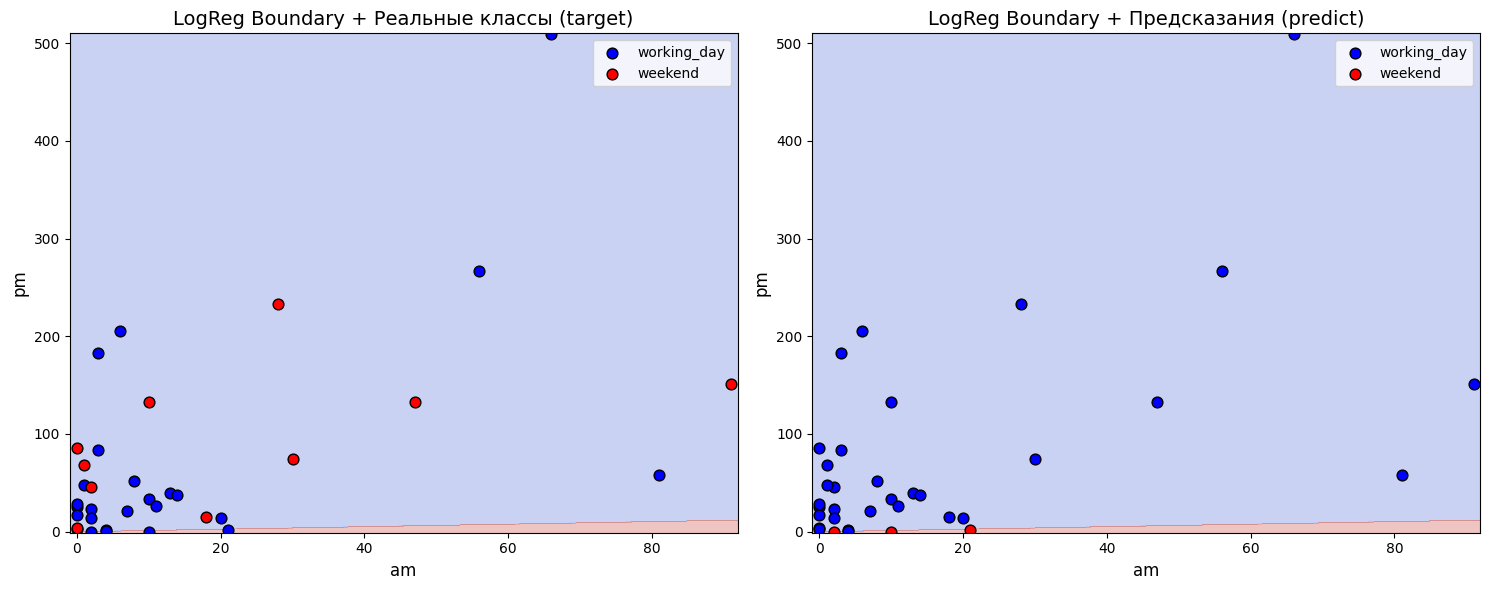

In [2]:
df = pd.read_csv('data/am_pm.csv')

X = df[['am', 'pm']]
y = df['target']

logreg = LogisticRegression(random_state=21, fit_intercept=False)
logreg.fit(X, y)


def plot_decision_boundary(model, X, y_labels, ax, title):
    x_min, x_max = X['am'].min() - 1, X['am'].max() + 1
    y_min, y_max = X['pm'].min() - 1, X['pm'].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_num = np.where(Z == 'working_day', 0, 1)
    Z_num = Z_num.reshape(xx.shape)

    ax.contourf(xx, yy, Z_num, alpha=0.3, cmap='coolwarm')

    working_days = X[y_labels == 'working_day']
    weekends = X[y_labels == 'weekend']
    
    ax.scatter(working_days['am'], working_days['pm'], color='blue', label='working_day', edgecolor='k', s=60)
    ax.scatter(weekends['am'], weekends['pm'], color='red', label='weekend', edgecolor='k', s=60)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('am', fontsize=12)
    ax.set_ylabel('pm', fontsize=12)
    ax.legend()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

plot_decision_boundary(logreg, X, df['target'], ax1, 'LogReg Boundary + Реальные классы (target)')

plot_decision_boundary(logreg, X, df['predict'], ax2, 'LogReg Boundary + Предсказания (predict)')

plt.tight_layout()
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

Accuracy после стандартизации: 0.7428571428571429
Accuracy наивного прогноза: 0.71429


/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero

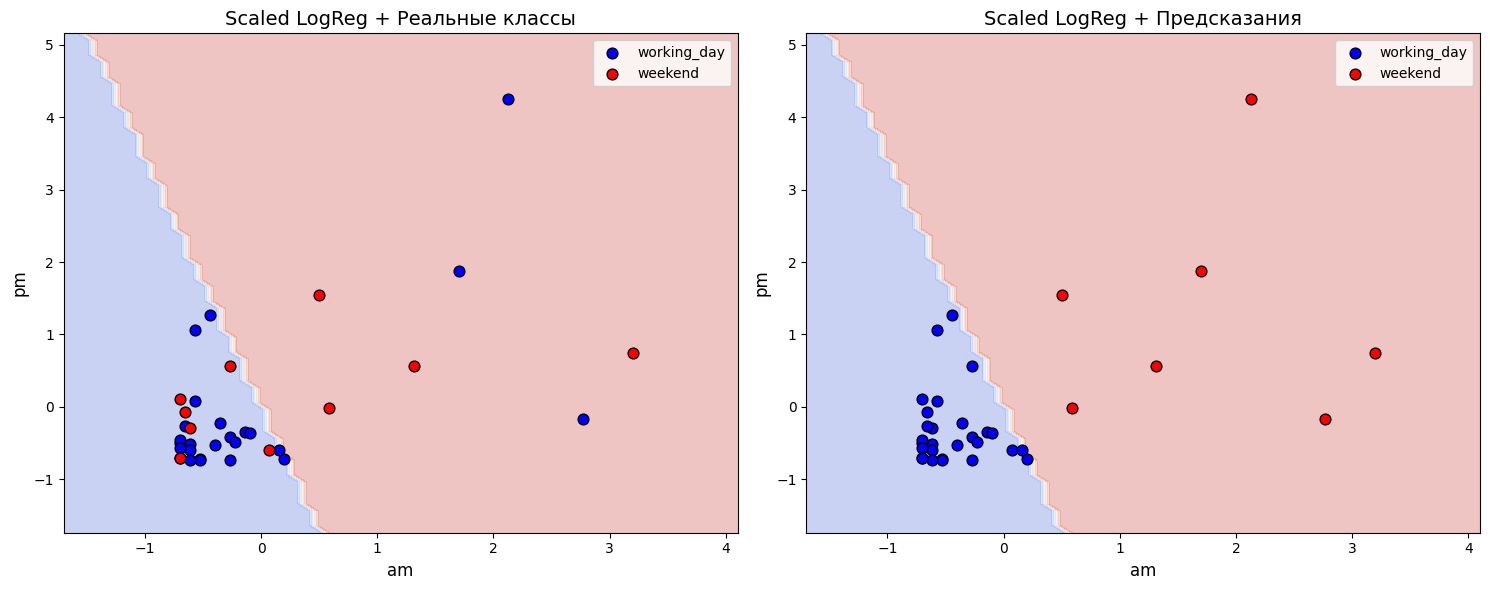

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=['am', 'pm'])

logreg_scaled = LogisticRegression(random_state=21, fit_intercept=False)
logreg_scaled.fit(X_scaled_df, y)

y_pred_scaled = logreg_scaled.predict(X_scaled_df)
accuracy_scaled = accuracy_score(y, y_pred_scaled)
print(f"Accuracy после стандартизации: {accuracy_scaled}")

most_popular_class = y.value_counts().idxmax()
naive_predictions = [most_popular_class] * len(y)
naive_accuracy = accuracy_score(y, naive_predictions)
print(f"Accuracy наивного прогноза: {naive_accuracy:.5f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

plot_decision_boundary(logreg_scaled, X_scaled_df, y, ax1, 'Scaled LogReg + Реальные классы')
plot_decision_boundary(logreg_scaled, X_scaled_df, y_pred_scaled, ax2, 'Scaled LogReg + Предсказания')

plt.tight_layout()
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

Ищем лучшее ядро для SVM:

Ядро 'linear': accuracy = 0.7142857142857143
Ядро 'poly': accuracy = 0.7428571428571429
Ядро 'rbf': accuracy = 0.7428571428571429
Ядро 'sigmoid': accuracy = 0.6857142857142857

Лучшее ядро: 'poly' с accuracy: 0.7428571428571429



/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


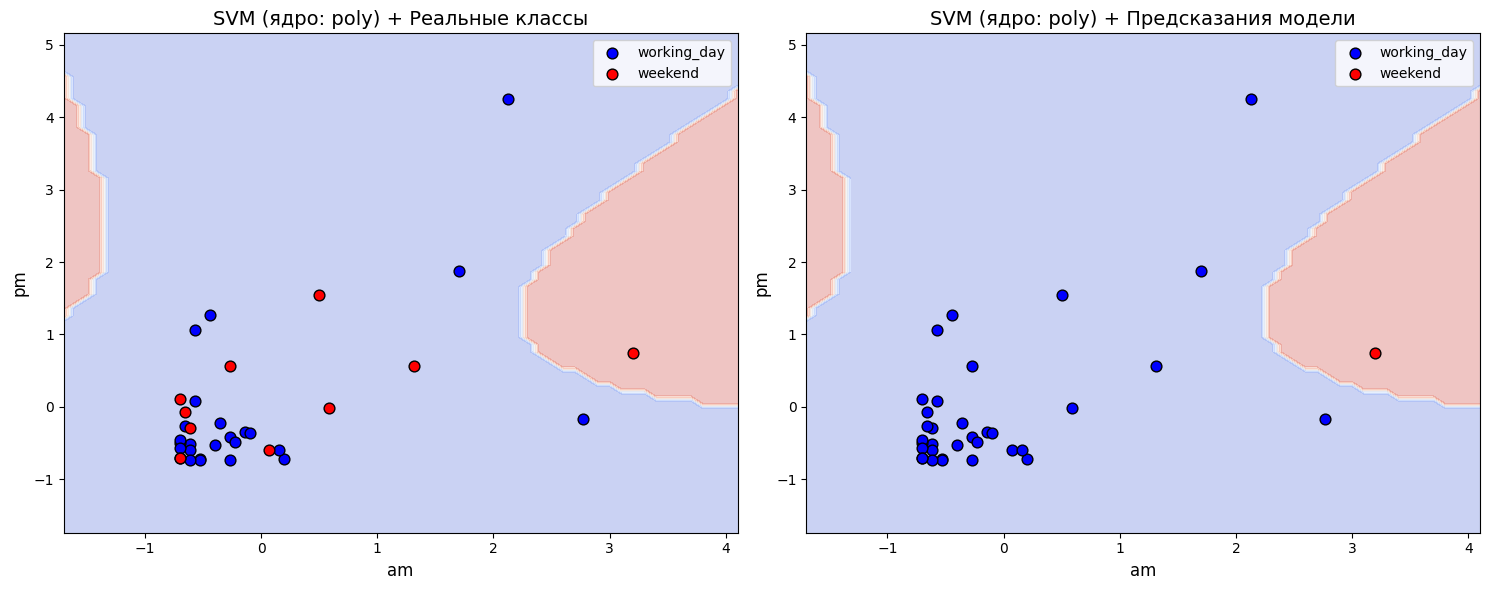

In [4]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_accuracy = 0
best_kernel = ''
best_svc_model = None

print("Ищем лучшее ядро для SVM:\n")

for kernel in kernels:
    svc = SVC(kernel=kernel, probability=True, random_state=21)
    svc.fit(X_scaled_df, y)
    y_pred = svc.predict(X_scaled_df)
    acc = accuracy_score(y, y_pred)
    print(f"Ядро '{kernel}': accuracy = {acc}")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_kernel = kernel
        best_svc_model = svc

print(f"\nЛучшее ядро: '{best_kernel}' с accuracy: {best_accuracy}\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

y_pred_best = best_svc_model.predict(X_scaled_df)

plot_decision_boundary(best_svc_model, X_scaled_df, y, ax1, f'SVM (ядро: {best_kernel}) + Реальные классы')
plot_decision_boundary(best_svc_model, X_scaled_df, y_pred_best, ax2, f'SVM (ядро: {best_kernel}) + Предсказания модели')

plt.tight_layout()
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

Accuracy Дерева решений (max_depth=4): 0.9428571428571428

max_depth=1: accuracy = 0.7714285714285715
max_depth=2: accuracy = 0.8571428571428571
max_depth=3: accuracy = 0.8857142857142857
max_depth=4: accuracy = 0.9428571428571428
max_depth=5: accuracy = 0.9714285714285714
max_depth=6: accuracy = 1.0
max_depth=7: accuracy = 1.0
max_depth=8: accuracy = 1.0
max_depth=9: accuracy = 1.0


/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


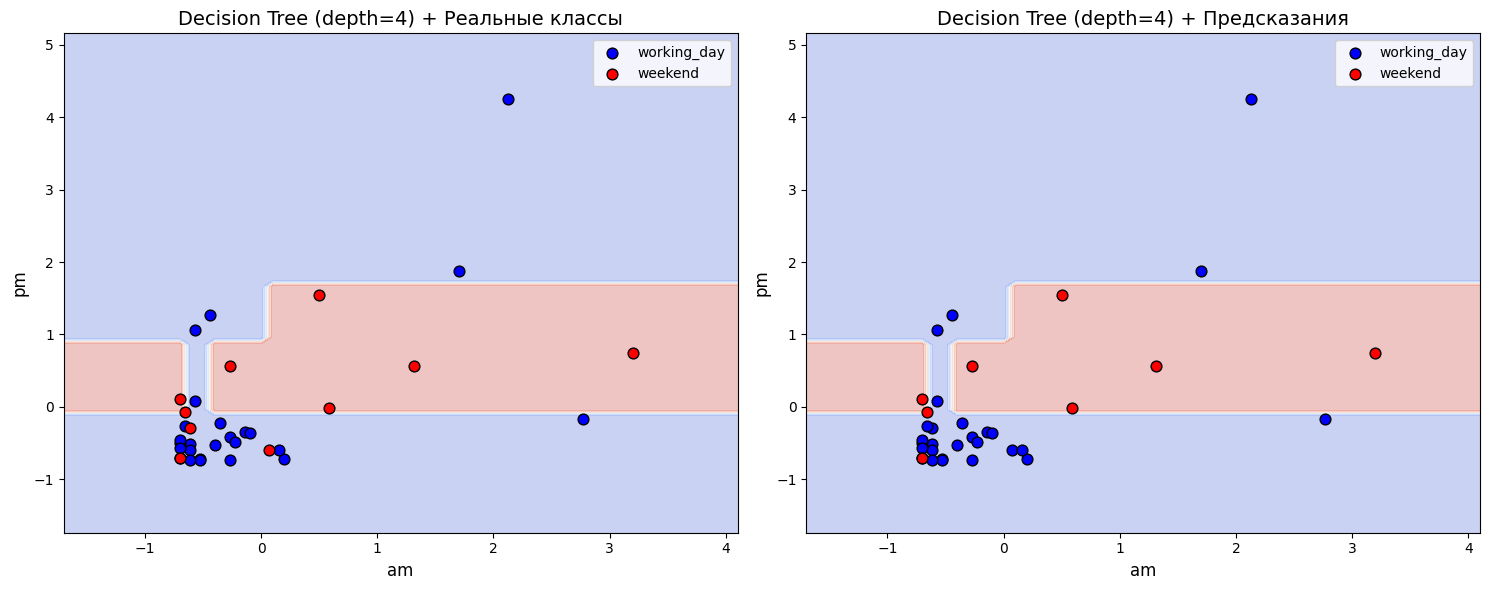

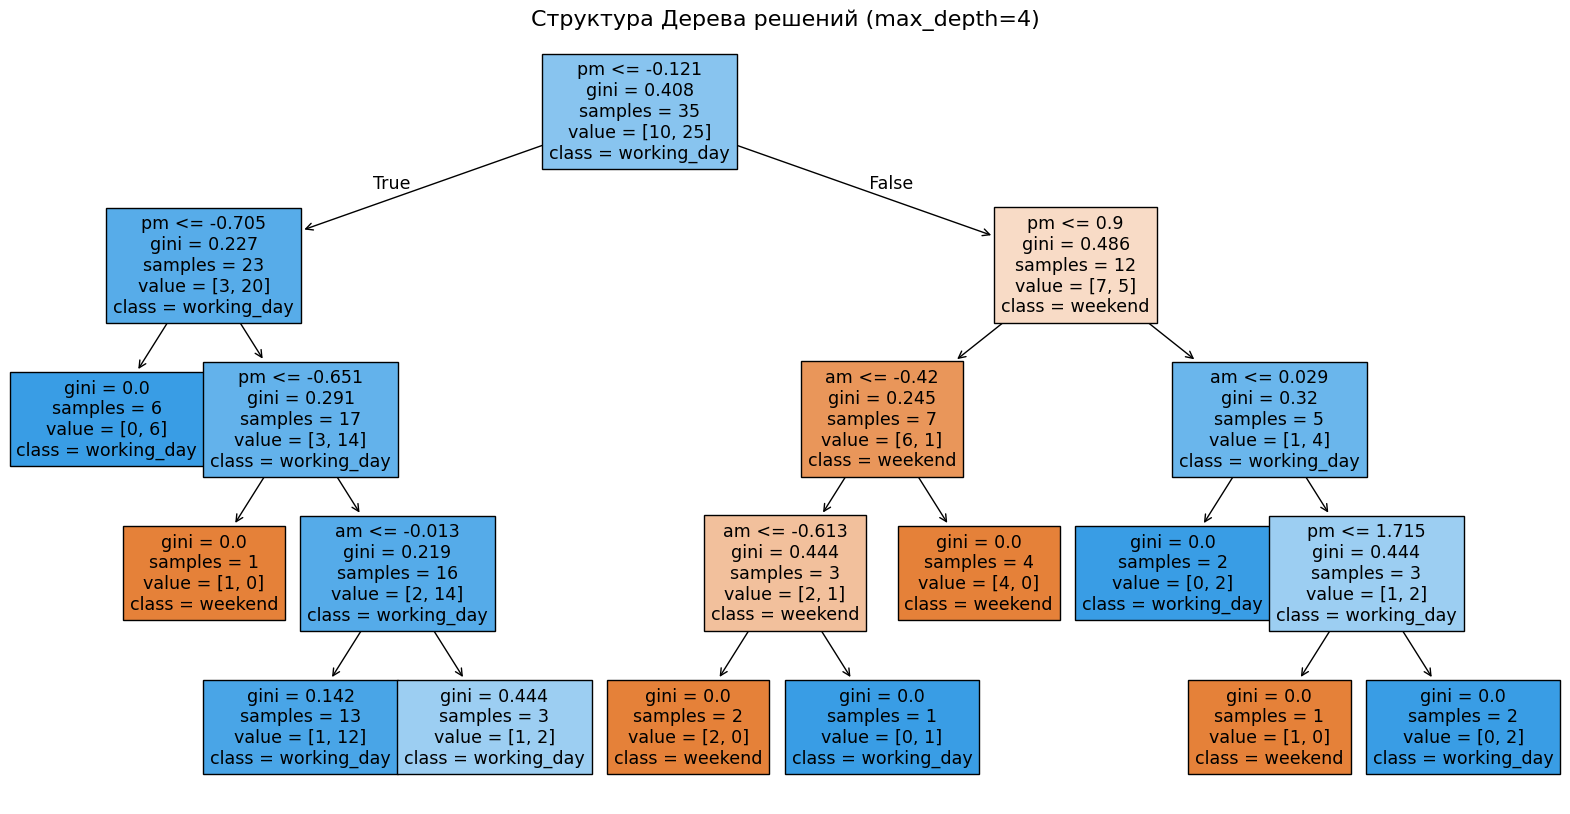

In [5]:
dtc = DecisionTreeClassifier(max_depth=4, random_state=42)
dtc.fit(X_scaled_df, y)

y_pred_dtc = dtc.predict(X_scaled_df)
print(f"Accuracy Дерева решений (max_depth=4): {accuracy_score(y, y_pred_dtc)}\n")

for depth in range(1, 10):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_scaled_df, y)
    acc = accuracy_score(y, model.predict(X_scaled_df))
    print(f"max_depth={depth}: accuracy = {acc}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plot_decision_boundary(dtc, X_scaled_df, y, ax1, 'Decision Tree (depth=4) + Реальные классы')
plot_decision_boundary(dtc, X_scaled_df, y_pred_dtc, ax2, 'Decision Tree (depth=4) + Предсказания')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dtc, 
          filled=True, 
          feature_names=['am', 'pm'], 
          class_names=dtc.classes_, 
          ax=ax)
plt.title('Структура Дерева решений (max_depth=4)', fontsize=16)
plt.show()

How many leaves in the visualized tree label days as working days?

4 labels